In [23]:
import os
import sys
from copy import deepcopy
from pathlib import Path

import einops
import matplotlib.pyplot as plt
import numpy as np
import pykoopman as pk
import seaborn as sns
import torch
from matrepr import mdisplay, mprint
from rich import print as rprint
from torch.nn.functional import mse_loss

from analysis.koopman import KoopmanWrapper
from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.trajectory import TrajectoryEngine, reshape_append_time
from nnscaling.utils import compute_model_accuracy, get_device, safetensors_metadata_parser
from nnscaling.visualization import plot_decision_boundary, plot_eigenvalues

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
NUM_TRAJ = 50  # Try to keep below 3_000
BATCH_SIZE = 2_048  # Number of Koopman inferences to run at once
DELAY_PARAM = 3  # Typically set to iterations - 2

In [25]:
# Project directory
project_dir = Path(os.getcwd()).parent

# Load original model
file_path = Path(project_dir, "model_saves/lotusroot_model.safetensors")
original_model = MLP.load_model(file_path, in_features=2).eval()

# Load scaled model
file_path = Path(project_dir, "model_saves/scaling/loc_1_scaled_lotusroot_model.safetensors")
scaled_model = ScaledModel.load_model(original_model, file_path).eval()

# Dataset config
metadata = safetensors_metadata_parser(file_path=file_path)
dataset_config = DatasetConfig(
    dataset_name=metadata["dataset"],
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

{'config': '[10, 8, 6, 3]', 'dataset': 'SunflowerDataset', 'nonlinearity': 'relu', 'out_features': '2'}


In [26]:
# Generate trajectories
trajectory_engine = TrajectoryEngine(
    dataset_config=dataset_config,
    scaled_model=scaled_model,
)
acts_dict = trajectory_engine.generate_trajectory(
    num_train=NUM_TRAJ,
    magic_number=-0.5,
    seed=0,
)

In [27]:
# Train states
train_states = acts_dict["scaled_train"]
test_states = acts_dict["scaled_test"]

rprint(
    f"Trajectory tensor: {train_states.shape}",
    "\n\[batch, state, iteration]",
)

train_states = reshape_append_time(acts_dict["scaled_train"])
rprint(
    f"Trajectory tensor: {train_states.shape}",
    "\n\[state, batch * iteration]",
)

Trajectory tensor: torch.Size([50, 10, 5]) 
[batch, state, iteration]

Trajectory tensor: torch.Size([10, 250]) 
[state, batch * iteration]

In [28]:
observable_fn = pk.observables.TimeDelay(delay=1, n_delays=DELAY_PARAM)
regressor = pk.regression.EDMD(svd_rank=40)

dmd_model = pk.Koopman(observables=observable_fn, regressor=regressor)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=3), regressor=EDMD(svd_rank=40))

(<Figure size 400x400 with 1 Axes>, <Axes: title={'center': 'h=3, r=50'}>)

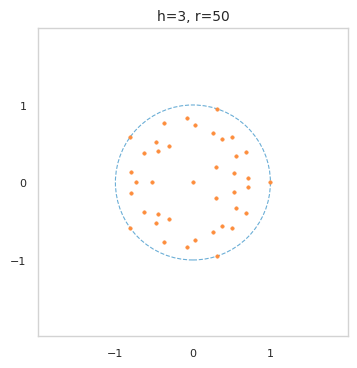

In [29]:
koop_eigenvals = np.diag(dmd_model.lamda)
filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.8]
plot_eigenvalues(
    eigenvalues_dict={(NUM_TRAJ, DELAY_PARAM): koop_eigenvals},
    num_trajectories_list=[NUM_TRAJ],
    num_delays_list=[DELAY_PARAM],
    tile_size=4,
)

In [30]:
koopman_scaled_model = KoopmanWrapper(scaled_model, dmd_model=dmd_model, n_delays=DELAY_PARAM)

torch.Size([40, 40])

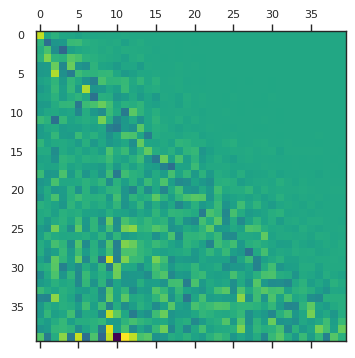

In [31]:
plt.matshow(koopman_scaled_model.tensor_A.T, cmap="viridis", norm="linear")
rprint(koopman_scaled_model.tensor_A.T.shape)

In [32]:
sample = 0
mod_test_states = einops.rearrange(test_states, "t s i -> s (t i)")
n_iterations = test_states.shape[-1]
mprint(test_states[sample, :, -1].numpy(), method="str")

# Xkoop = dmd_model.simulate(
#     mod_test_states.numpy()[
#         :,
#         sample * n_iterations : (sample * n_iterations) + DELAY_PARAM + 1,
#     ].T,
#     n_steps=(12) - 1 - DELAY_PARAM,
# )
# mprint(Xkoop[:, :])


Xkoop = koopman_scaled_model.simulate(
    x0=test_states[:BATCH_SIZE], n_steps=n_iterations - DELAY_PARAM - 1
)
mprint(Xkoop[sample, :, -1].numpy().T)

<length=10, 10 'float32' elements, array>
   0       1       2       3            6       7        8        9
[0.0000  0.0000  0.0000  0.6154  ...  0.0000  0.0000  -0.5000  -0.5000]
<length=10, 10 'float32' elements, array>
   0       1        2       3             6       7        8        9
[0.1214  0.0108  -0.1136  0.4686  ...  -0.0783  0.1394  -0.5503  -0.3822]


<Axes: ylabel='Count'>

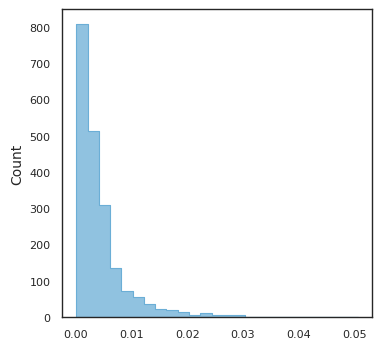

In [33]:
loss_tensor = mse_loss(test_states[:BATCH_SIZE, :, -1], Xkoop[:, :, -1], reduction="none")
loss_mean = torch.mean(loss_tensor, dim=1)

sns.histplot(
    loss_mean.numpy(),
    bins=25,
    kde=False,
    color=aesthetics.SeabornColors.blue,
    element="step",  # {“bars”, “step”, “poly”}
)

/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")


Testing Accuracy: 0.5453333258628845


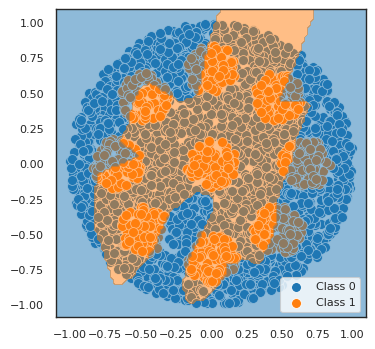

In [34]:
print(f"Testing Accuracy: {compute_model_accuracy(koopman_scaled_model.to('cpu'), dataset)}")

plot_decision_boundary(
    koopman_scaled_model,
    koopman_scaled_model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1, 2],
)